In [ ]:
#Task 2: Predict Future Stock Prices (Short-Term)
#Objective:
#Use historical stock data to predict the next day&#39;s closing price.
#Dataset:
#Stock market data from Yahoo Finance (retrieved using the yfinance Python library)
#Instructions:
#● Select a stock (e.g., Apple, Tesla).
#● Load historical data using the yfinance library.
#● Use features like Open, High, Low, and Volume to predict the next Close price.
#● Train a Linear Regression or Random Forest model.
#● Plot actual vs predicted closing prices for comparison.

In [3]:
!pip install yfinance

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
%matplotlib inline

ticker = "AAPL"
stock_data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data.columns = stock_data.columns.get_level_values(0)

print(f"Successfully downloaded {len(stock_data)} rows of data for {ticker}!")
display(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Successfully downloaded 1255 rows of data for AAPL!


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,125.740852,129.821767,123.165986,129.734322,143301900
2021-01-05,127.295464,128.004777,124.788613,125.235577,97664900
2021-01-06,123.010498,127.334331,122.796735,124.098745,155088000
2021-01-07,127.208061,127.897937,124.234823,124.720647,109578200
2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200


In [5]:
df_stock = stock_data.copy()

df_stock["Next_Close"] = df_stock["Close"].shift(-1)

df_stock.dropna(inplace=True)

features = ["Open", "High", "Low", "Volume", "Close"]
X = df_stock[features]
y = df_stock["Next_Close"]

print("Features (X) sample:")
display(X.head(2))
print("\nTarget (y) sample (Notice it matches the next day's close):")
display(y.head(2))

Features (X) sample:


Price,Open,High,Low,Volume,Close
Date,,,,,
2021-01-04,129.734322,129.821767,123.165986,143301900,125.740852
2021-01-05,125.235577,128.004777,124.788613,97664900,127.295464



Target (y) sample (Notice it matches the next day's close):


Date
2021-01-04    127.295464
2021-01-05    123.010498
Name: Next_Close, dtype: float64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MODEL PERFORMANCE METRICS ===")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R² Score (Variance Explained): {r2:.4f}")

=== MODEL PERFORMANCE METRICS ===
Mean Absolute Error (MAE): $6.89
Root Mean Squared Error (RMSE): $9.86
R² Score (Variance Explained): 0.8616


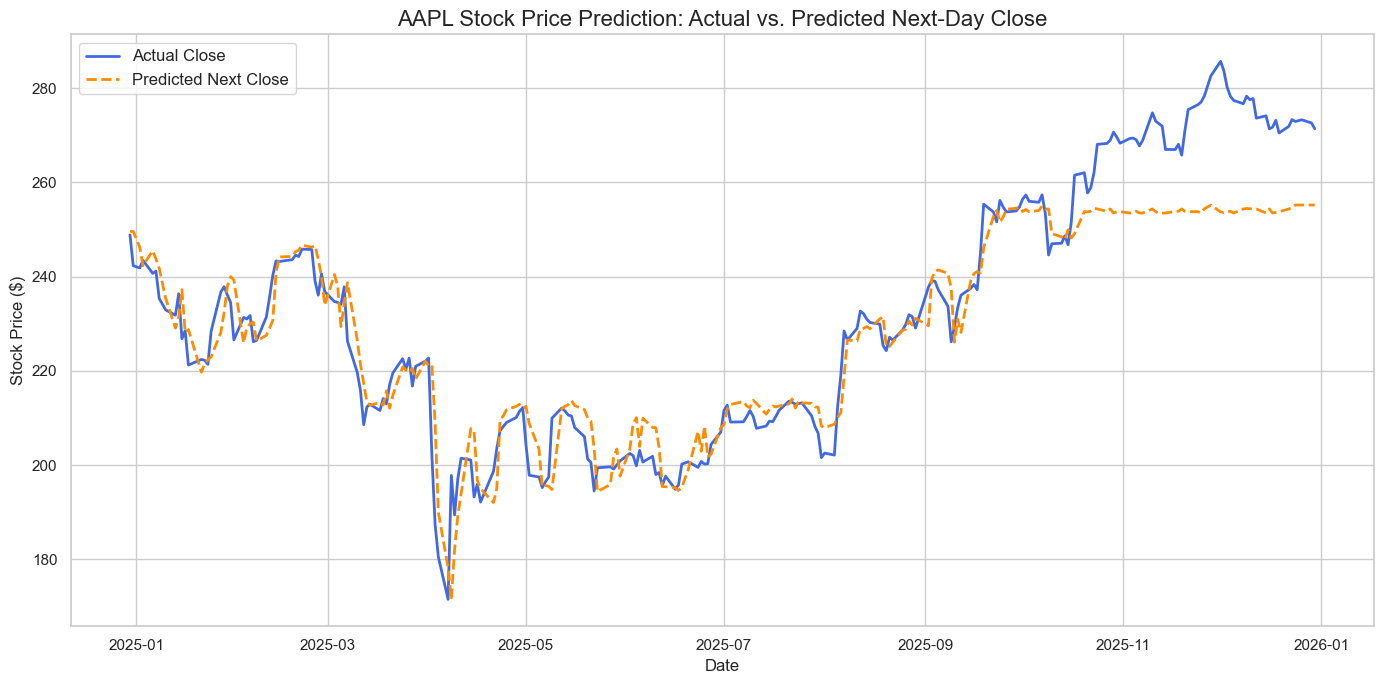

In [7]:
results = pd.DataFrame(
    {"Actual": y_test.values, "Predicted": y_pred}, index=y_test.index
)

plt.figure(figsize=(14, 7))
plt.plot(results.index, results["Actual"], label="Actual Close", color="royalblue", lw=2)
plt.plot(
    results.index,
    results["Predicted"],
    label="Predicted Next Close",
    color="darkorange",
    linestyle="--",
    lw=2,
)

plt.title(
    f"{ticker} Stock Price Prediction: Actual vs. Predicted Next-Day Close",
    fontsize=16,
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Stock Price ($)", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()